In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
class BoreasRadarDataset(Dataset):
    def __init__(self, data_dir, patches_per_frame=400):
        self.data_dir = Path(data_dir)
        self.patches_per_frame = patches_per_frame
        
        # Grab sorted lists of the batched arrays
        self.patch_files = sorted(list((self.data_dir / "input/patch_arrays").glob("*.npy")))
        self.label_files = sorted(list((self.data_dir / "labels").glob("*.npy")))
        
        self.num_frames = len(self.patch_files)
        print(f"Found {self.num_frames} frames. Total samples: {self.__len__()}")
        
    def __len__(self):
        return self.num_frames * self.patches_per_frame
        
    def __getitem__(self, idx):
        # Locate the correct file and sub-index
        frame_idx = idx // self.patches_per_frame
        patch_idx = idx % self.patches_per_frame
        
        # Memory map the specific arrays
        batched_patches = np.load(self.patch_files[frame_idx], mmap_mode='r')
        batched_labels = np.load(self.label_files[frame_idx], mmap_mode='r')
        
        # Extract to RAM and convert to 32-bit floats
        # Adding a channel dimension [1, 50, 50] for the CNN
        patch = np.expand_dims(batched_patches[patch_idx].copy(), axis=0).astype(np.float32)
        label = batched_labels[patch_idx].copy().astype(np.float32)
        
        return torch.from_numpy(patch), torch.from_numpy(label)

In [3]:
dataset = BoreasRadarDataset(data_dir="/media/asrl/Extreme SSD/ASRL/boreas/data/boreas-2024-12-03-12-54")
dataloader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=4)
patches, targets = next(iter(dataloader))
print("Batch shape:", patches.shape) # Should be [32, 1, 50, 50]

Found 141 frames. Total samples: 56400
Batch shape: torch.Size([32, 1, 50, 50])


In [20]:
import torch.nn as nn
import torch

class TwoHeadedRadarMLP(nn.Module):
    def __init__(self, input_size=50, output_bins=6848):
        super().__init__()
        
        flattened_size = input_size * input_size 
        
        # --- THE SHARED BACKBONE ---
        # Extracts the geometric relationship from the Cartesian grid
        self.backbone = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flattened_size, 1024),
            nn.BatchNorm1d(1024),
            nn.LeakyReLU(0.1),
            nn.Dropout(p=0.3),
            nn.Linear(1024, 1024),
            nn.BatchNorm1d(1024),
            nn.LeakyReLU(0.1),
            nn.Dropout(p=0.3)
        )
        
        # --- HEAD 1: THE LOCATOR (Classification) ---
        # Answers: "Is there a physical object in this bin?"
        self.locator_head = nn.Sequential(
            nn.Linear(1024, output_bins)
        )
        
        # --- HEAD 2: THE ESTIMATOR (Regression) ---
        # Answers: "How reflective is the object?"
        self.estimator_head = nn.Sequential(
            nn.Linear(1024, output_bins),
            nn.Sigmoid() # Outputs the normalized intensity from 0.0 to 1.0
        )

    def forward(self, x):
        features = self.backbone(x)
        
        probability_mask = self.locator_head(features)
        peak_intensity = self.estimator_head(features)
        
        # Return both predictions!
        return probability_mask, peak_intensity

In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TwoHeadedRadarMLP().to(device)
dummy_input = torch.randn(32, 1, 50, 50).to(device)
probability_mask, peak_intensity = model(dummy_input)
print("Output shape:", probability_mask.shape)
print("Output shape:", peak_intensity.shape) # Should be [32, 400]

Output shape: torch.Size([32, 6848])
Output shape: torch.Size([32, 6848])


In [22]:
class ZeroInflatedLoss(nn.Module):
    def __init__(self, bce_weight=1.0, mse_weight=5.0, pos_weight_val=10.0):
        super().__init__()
        self.bce_weight = bce_weight
        self.mse_weight = mse_weight
        pos_weight_tensor = torch.tensor([pos_weight_val])
        self.bce_loss = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
        
    def forward(self, prob_preds, int_preds, targets):
        # 1. Create the binary ground truth (1 if peak exists, 0 if empty)
        binary_targets = (targets > 0.0).float()
        
        # 2. LOCATOR LOSS: Teach it to find the peaks
        loss_locator = self.bce_loss(prob_preds, binary_targets)
        
        # 3. ESTIMATOR LOSS: Teach it the exact intensity
        raw_mse = (int_preds - targets) ** 2
        
        # --- THE MASK ---
        # Multiply by binary_targets. If the ground truth bin is 0, the error becomes 0!
        masked_mse = raw_mse * binary_targets 
        
        # Calculate the mean error, but ONLY across the actual peaks 
        # (Clamp prevents division by zero if a batch has no peaks)
        num_peaks = binary_targets.sum().clamp(min=1.0) 
        loss_estimator = masked_mse.sum() / num_peaks
        
        # 4. Combine the losses
        total_loss = (self.bce_weight * loss_locator) + (self.mse_weight * loss_estimator)
        
        return total_loss

In [23]:
import torch
import torch.optim as optim
import torch.nn as nn
from torch.utils.data import DataLoader

# 1. Device configuration 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 2. Dynamically get the required output size from the first label
# (Assuming 'dataset' is already initialized)
sample_patch, sample_label = dataset[0]
num_radar_bins = sample_label.shape[0]

# 3. Initialize the NEW Two-Headed network
model = TwoHeadedRadarMLP(input_size=50, output_bins=num_radar_bins).to(device)

# 4. Define Optimizer and the NEW Masked Loss Function
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = ZeroInflatedLoss(bce_weight=1.0, mse_weight=5.0, pos_weight_val=10.0).to(device)

# 5. THE OVERFIT SETUP: Grab exactly ONE batch and hold it in memory
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)
overfit_patches, overfit_labels = next(iter(dataloader))

# Move this specific batch to the GPU permanently
overfit_patches = overfit_patches.to(device)
overfit_labels = overfit_labels.to(device)

print(f"Grabbed 1 batch of {overfit_patches.shape[0]} samples.")
print(f"Patch shape: {overfit_patches.shape} | Label shape: {overfit_labels.shape}")

# 6. The Overfitting Loop
num_epochs = 1000 

print("Starting two-headed overfitting test...")

for epoch in range(num_epochs):
    model.train() 
    
    # Step A: Zero out the gradients
    optimizer.zero_grad()
    
    # Step B: Forward Pass (Now outputs TWO predictions)
    prob_preds, int_preds = model(overfit_patches)
    
    # Step C: Calculate the Masked Loss
    loss = criterion(prob_preds, int_preds, overfit_labels)
    
    # Step D: Backward Pass
    loss.backward()
    
    # Step E: Optimize (Update weights)
    optimizer.step()
    
    # Print an update every 20 epochs to watch it drop
    if (epoch + 1) % 20 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {loss.item():.6f}")

print("Overfitting test complete!")

Using device: cuda
Grabbed 1 batch of 32 samples.
Patch shape: torch.Size([32, 1, 50, 50]) | Label shape: torch.Size([32, 6848])
Starting two-headed overfitting test...
Epoch [1/1000] | Loss: 1.656646
Epoch [20/1000] | Loss: 0.282631
Epoch [40/1000] | Loss: 0.151682
Epoch [60/1000] | Loss: 0.083863
Epoch [80/1000] | Loss: 0.053276
Epoch [100/1000] | Loss: 0.038836
Epoch [120/1000] | Loss: 0.029275
Epoch [140/1000] | Loss: 0.026303
Epoch [160/1000] | Loss: 0.021695
Epoch [180/1000] | Loss: 0.019706
Epoch [200/1000] | Loss: 0.018315
Epoch [220/1000] | Loss: 0.016538
Epoch [240/1000] | Loss: 0.016361
Epoch [260/1000] | Loss: 0.015236
Epoch [280/1000] | Loss: 0.011754
Epoch [300/1000] | Loss: 0.011319
Epoch [320/1000] | Loss: 0.011210
Epoch [340/1000] | Loss: 0.010658
Epoch [360/1000] | Loss: 0.010484
Epoch [380/1000] | Loss: 0.008603
Epoch [400/1000] | Loss: 0.007872
Epoch [420/1000] | Loss: 0.008029
Epoch [440/1000] | Loss: 0.008719
Epoch [460/1000] | Loss: 0.006985
Epoch [480/1000] | Lo

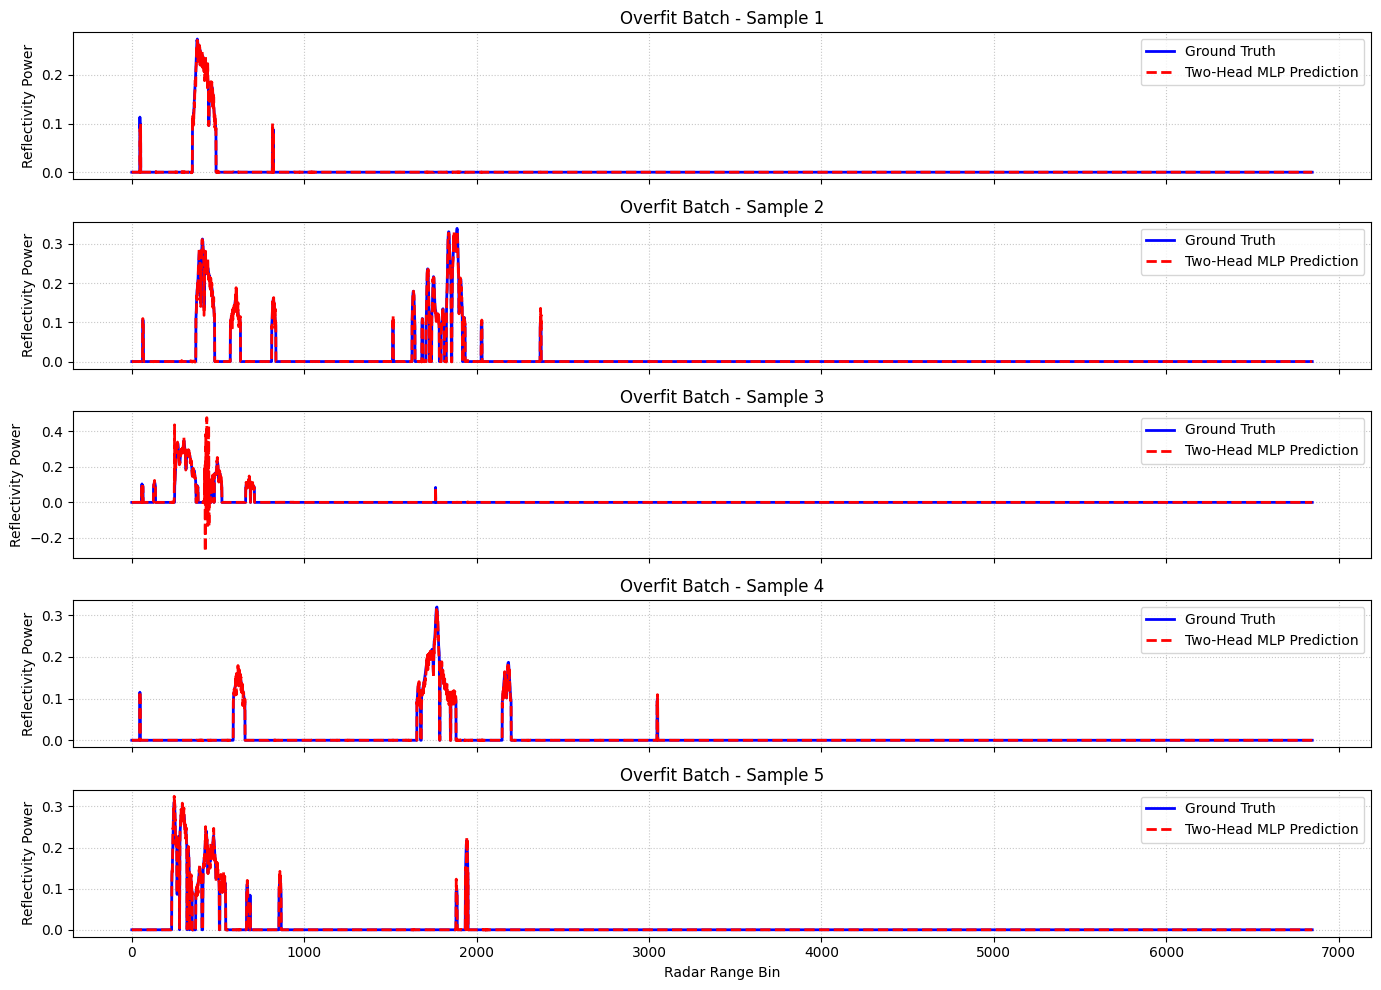

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# 1. Set the model to evaluation mode (Crucial for inference!)
model.eval()

# 2. Run the forward pass without tracking gradients (saves memory/time)
with torch.no_grad():
    # Unpack the two heads from the new architecture
    prob_preds, int_preds = model(overfit_patches)
    
    # --- THE MAGIC MULTIPLICATION ---
    # Multiply the probability mask by the estimated intensity
    final_preds = prob_preds * int_preds

# 3. Move the data off the GPU and convert to NumPy
preds_np = final_preds.cpu().numpy()
labels_np = overfit_labels.cpu().numpy()

# 4. Set up a Matplotlib figure to plot 5 different examples from the batch
num_examples = 5
fig, axes = plt.subplots(num_examples, 1, figsize=(14, 10), sharex=True) # Slightly wider/taller for 5 plots

for i in range(num_examples):
    ax = axes[i]
    
    # Plot Ground Truth in Blue
    ax.plot(labels_np[i], label="Ground Truth", color='blue', linewidth=2)
    
    # Plot Prediction in Red (Dashed so you can see the blue underneath)
    # Updated label to reflect the new architecture!
    ax.plot(preds_np[i], label="Two-Head MLP Prediction", color='red', linestyle='--', linewidth=2)
    
    ax.set_title(f"Overfit Batch - Sample {i+1}")
    ax.set_ylabel("Reflectivity Power")
    ax.grid(True, linestyle=':', alpha=0.7)
    
    # Put legend in upper right so it doesn't block the early radar bins
    ax.legend(loc="upper right")

# Format the bottom X-axis
axes[-1].set_xlabel("Radar Range Bin")
plt.tight_layout()
plt.show()

Epoch [20/20] | Train Loss: 0.32267 | Valid Loss: 0.61985


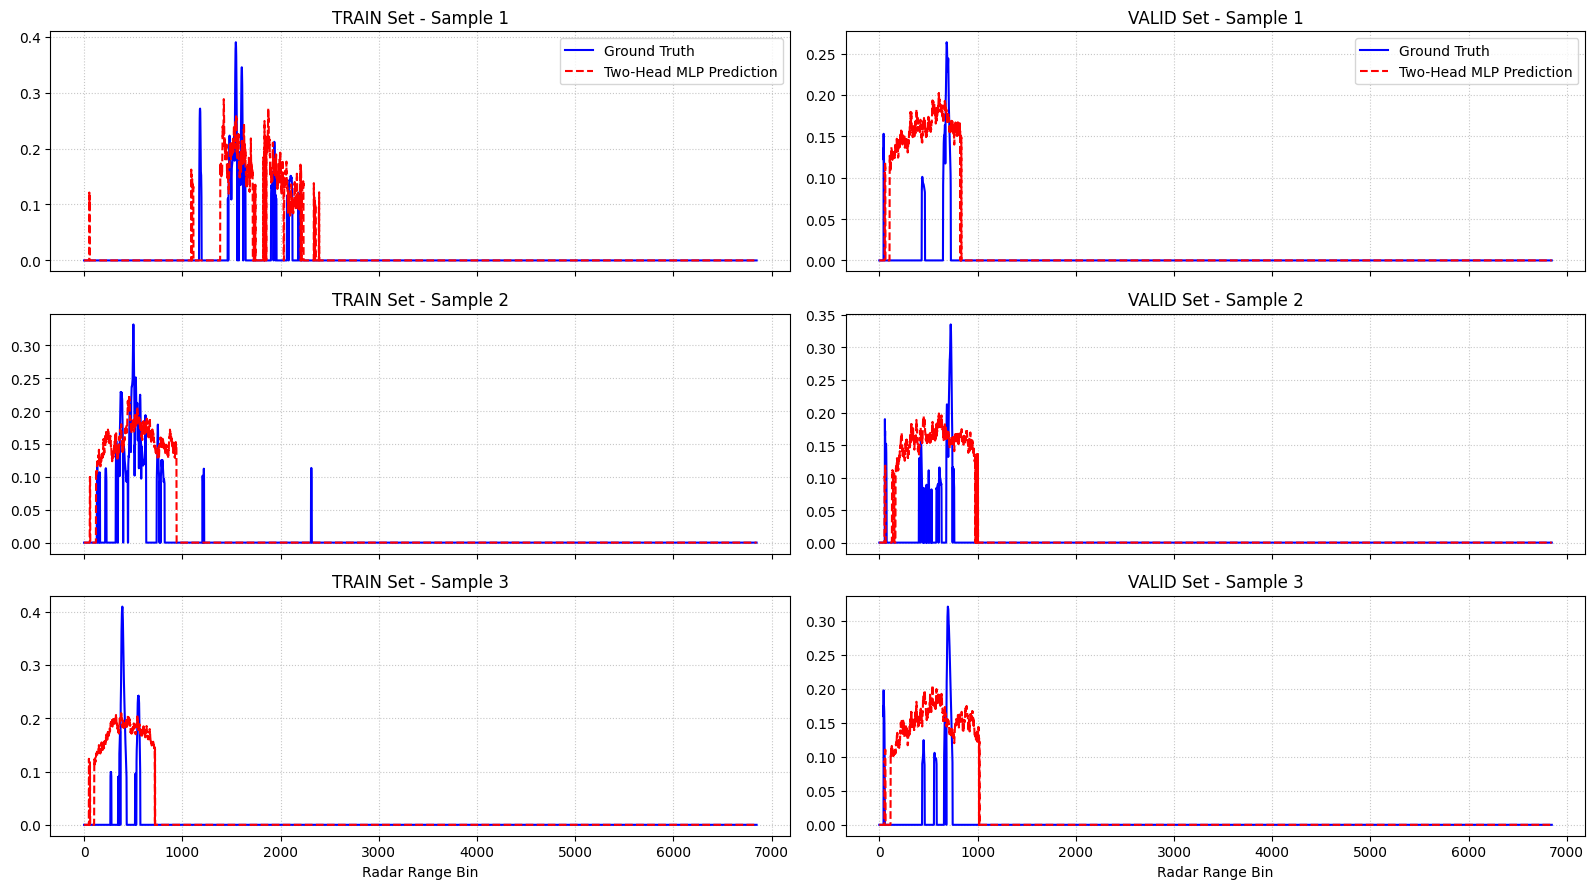

Training Complete!


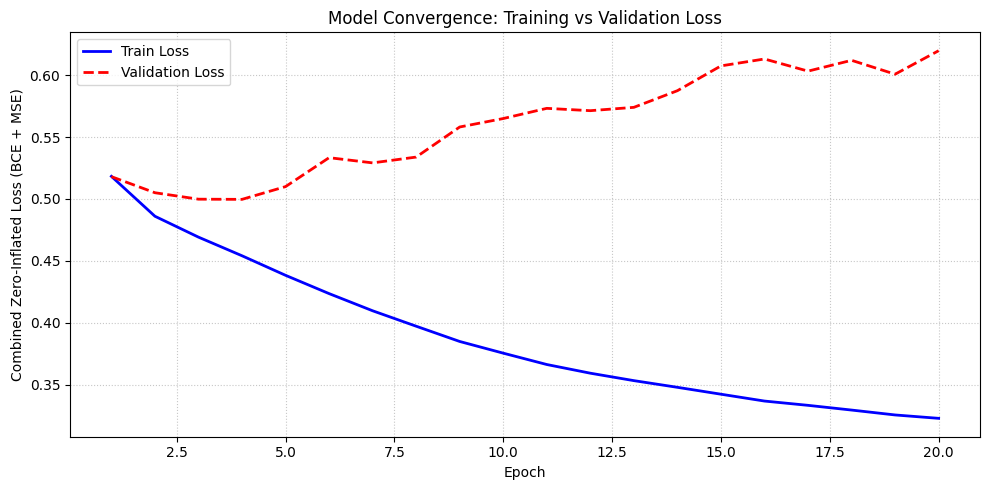

In [25]:
import torch
import torch.optim as optim
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import IPython.display as display
import numpy as np

# ==========================================
# 1. CHRONOLOGICAL DATASET SPLITTING (BY FRAME)
# ==========================================
# We must split by full 360-degree sweeps, not by individual azimuths
azimuths_per_frame = 400 # Adjust if your Boreas extraction uses a different number
total_frames = len(dataset) // azimuths_per_frame

train_frames = int(0.70 * total_frames) 
valid_frames = int(0.15 * total_frames) 
test_frames = total_frames - train_frames - valid_frames 

# Calculate exact index cutoffs
train_end_idx = train_frames * azimuths_per_frame
valid_end_idx = train_end_idx + (valid_frames * azimuths_per_frame)

# Create chronological subsets that slice cleanly between frames
train_dataset = Subset(dataset, range(0, train_end_idx))
valid_dataset = Subset(dataset, range(train_end_idx, valid_end_idx))

# The test set takes the rest (should naturally be a multiple of azimuths_per_frame)
test_dataset = Subset(dataset, range(valid_end_idx, len(dataset)))

print(f"Total Frames: {total_frames}")
print(f"Frame Split -> Train: {train_frames} | Valid: {valid_frames} | Test: {test_frames}")
print(f"Patch Split -> Train: {len(train_dataset)} | Valid: {len(valid_dataset)} | Test: {len(test_dataset)}")

# Create DataLoaders (Remember to use your worker_init_fn if using multiple workers!)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# ==========================================
# 2. MODEL & HYPERPARAMETER SETUP
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize the Two-Headed MLP
model = TwoHeadedRadarMLP(input_size=50, output_bins=num_radar_bins).to(device)

optimizer = optim.Adam(model.parameters(), lr=0.001)

# Initialize the Zero-Inflated Loss
criterion = ZeroInflatedLoss(bce_weight=1.0, mse_weight=5.0, pos_weight_val=10.0).to(device)
torch.manual_seed(1000)

num_epochs = 20
plot_every_n_epochs = 1  
samples_to_plot = 3      

# Arrays to track loss over time for the final plot
history_train_loss = []
history_valid_loss = []

# ==========================================
# 2.5 GRAB FIXED BATCHES FOR PLOTTING
# ==========================================
fixed_train_patches, fixed_train_labels = next(iter(train_loader))
fixed_valid_patches, fixed_valid_labels = next(iter(valid_loader))

fixed_train_patches = fixed_train_patches.to(device)
fixed_valid_patches = fixed_valid_patches.to(device)

fixed_train_labels_np = fixed_train_labels.numpy()
fixed_valid_labels_np = fixed_valid_labels.numpy()

# ==========================================
# 3. THE TRAINING & VALIDATION LOOP
# ==========================================
print("Starting Full Training with Side-by-Side Monitoring...")

for epoch in range(num_epochs):
    # --- TRAINING PHASE ---
    model.train() 
    train_loss = 0.0
    
    for patches, labels in train_loader:
        patches, labels = patches.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        # Forward pass: Unpack both heads
        prob_preds, int_preds = model(patches)
        
        # Calculate masked loss
        loss = criterion(prob_preds, int_preds, labels)
        
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        
    avg_train_loss = train_loss / len(train_loader)
    history_train_loss.append(avg_train_loss)
    
    # --- VALIDATION & PLOTTING PHASE ---
    if (epoch + 1) % plot_every_n_epochs == 0 or epoch == 0:
        model.eval() 
        valid_loss = 0.0
        
        with torch.no_grad():
            for val_patches, val_labels in valid_loader:
                val_patches, val_labels = val_patches.to(device), val_labels.to(device)
                
                # Unpack both heads
                val_prob, val_int = model(val_patches)
                batch_loss = criterion(val_prob, val_int, val_labels)
                
                valid_loss += batch_loss.item()
                
        avg_valid_loss = valid_loss / len(valid_loader)
        history_valid_loss.append(avg_valid_loss)
        
        # --- PLOT THE LIVE WAVEFORM RESULTS ---
        with torch.no_grad():
            # Get predictions for the fixed plots (Output 1 is raw logits!)
            t_prob_logits, t_int = model(fixed_train_patches)
            v_prob_logits, v_int = model(fixed_valid_patches)
            
            # 1. Convert logits back to readable probabilities (0.0 to 1.0)
            t_prob = torch.sigmoid(t_prob_logits)
            v_prob = torch.sigmoid(v_prob_logits)
            
            # 2. Apply the hard threshold mask! (1.0 if > 50% confident, else 0.0)
            t_mask = (t_prob > 0.5).float()
            v_mask = (v_prob > 0.5).float()
            
            # 3. Multiply the clean mask by the intensities
            train_preds_np = (t_mask * t_int).cpu().numpy()
            valid_preds_np = (v_mask * v_int).cpu().numpy()
            
        display.clear_output(wait=True) 
        
        fig, axes = plt.subplots(samples_to_plot, 2, figsize=(16, 3 * samples_to_plot), sharex=True)
        print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.5f} | Valid Loss: {avg_valid_loss:.5f}")
        
        if samples_to_plot == 1: axes = np.expand_dims(axes, axis=0)
            
        for i in range(samples_to_plot):
            # Left Column: TRAINING
            ax_train = axes[i, 0]
            ax_train.plot(fixed_train_labels_np[i], label="Ground Truth", color='blue', linewidth=1.5)
            ax_train.plot(train_preds_np[i], label="Two-Head MLP Prediction", color='red', linestyle='--', linewidth=1.5)
            ax_train.set_title(f"TRAIN Set - Sample {i+1}")
            ax_train.grid(True, linestyle=':', alpha=0.7)
            if i == 0: ax_train.legend(loc="upper right")

            # Right Column: VALIDATION
            ax_valid = axes[i, 1]
            ax_valid.plot(fixed_valid_labels_np[i], label="Ground Truth", color='blue', linewidth=1.5)
            ax_valid.plot(valid_preds_np[i], label="Two-Head MLP Prediction", color='red', linestyle='--', linewidth=1.5)
            ax_valid.set_title(f"VALID Set - Sample {i+1}")
            ax_valid.grid(True, linestyle=':', alpha=0.7)
            if i == 0: ax_valid.legend(loc="upper right")
            
        axes[-1, 0].set_xlabel("Radar Range Bin")
        axes[-1, 1].set_xlabel("Radar Range Bin")
        plt.tight_layout()
        plt.show()

print("Training Complete!")

# ==========================================
# 4. FINAL LOSS CURVE PLOT
# ==========================================
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), history_train_loss, label='Train Loss', color='blue', linewidth=2)

# If plotting validation every N epochs, adjust the x-axis for validation loss
val_x_axis = [i for i in range(1, num_epochs + 1) if i % plot_every_n_epochs == 0 or i == 1]
plt.plot(val_x_axis, history_valid_loss, label='Validation Loss', color='red', linestyle='--', linewidth=2)

plt.title("Model Convergence: Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Combined Zero-Inflated Loss (BCE + MSE)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

In [13]:
# ==========================================
# 1. SAVE THE CURRENT MODEL
# ==========================================
save_path = "model_weights/two_headed_MLP.pth"
torch.save(model.state_dict(), save_path)
print(f"Model successfully saved to {save_path}")

Model successfully saved to model_weights/two_headed_MLP.pth


Running inference on the test set...
Average Test Loss: 0.624939
Successfully reconstructed 22 full Polar Radar frames!
Polar array shape: (22, 400, 6848)


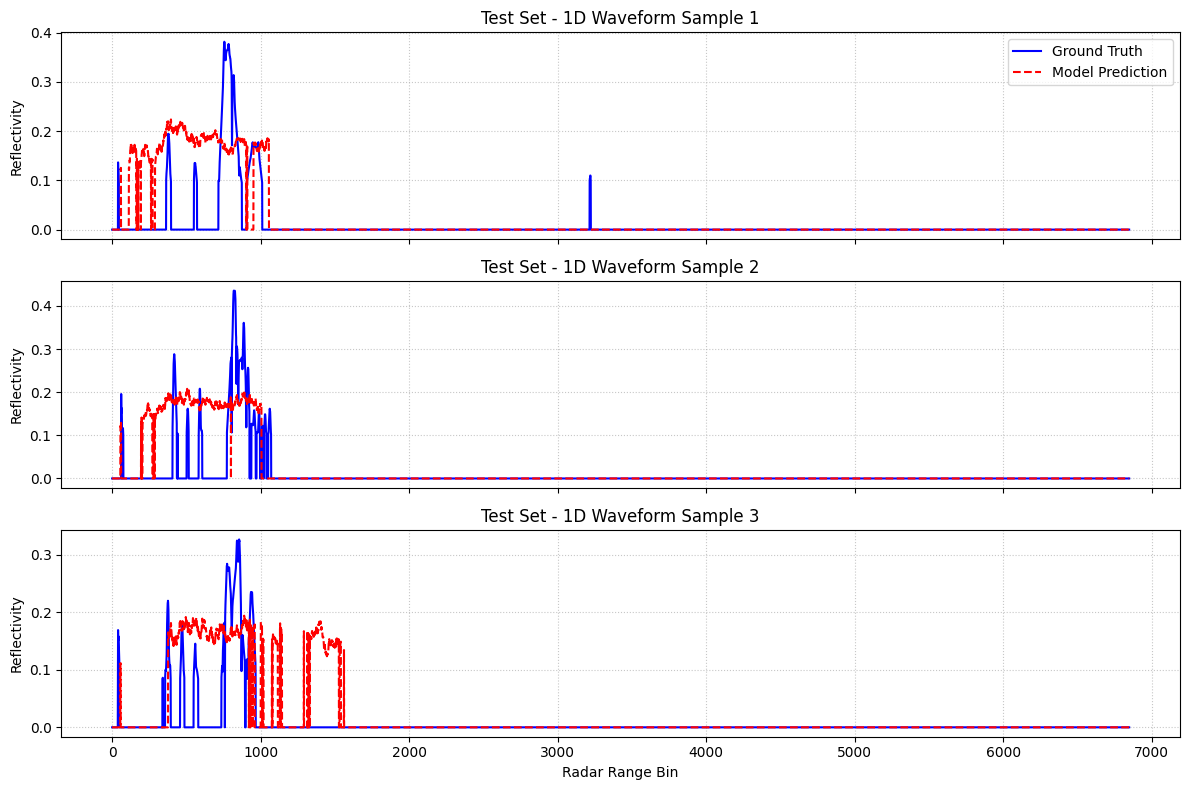

In [26]:
# ==========================================
# 2. RUN INFERENCE ON THE ENTIRE TEST SET
# ==========================================
print("Running inference on the test set...")
model.eval()

all_test_preds = []
all_test_labels = []
test_loss = 0.0

with torch.no_grad():
    for patches, labels in test_loader:
        # Move BOTH to device for loss calculation
        patches = patches.to(device)
        labels = labels.to(device)
        
        # 1. Forward pass: Unpack both heads (prob_preds are RAW LOGITS)
        prob_preds, int_preds = model(patches)
        
        # 2. Calculate test loss using the criterion (it expects raw logits!)
        batch_loss = criterion(prob_preds, int_preds, labels)
        test_loss += batch_loss.item()
        
        # --- THE HARD THRESHOLD ---
        # 3. Convert raw logits back into probabilities (0.0 to 1.0)
        probabilities = torch.sigmoid(prob_preds)
        
        # 4. Create the binary mask (1.0 if > 50% confident, else 0.0)
        confidence_threshold = 0.5
        hard_mask = (probabilities > confidence_threshold).float()
        
        # 5. Apply the mask to the Estimator's intensity predictions
        preds = hard_mask * int_preds 
        
        # Move back to CPU and store
        all_test_preds.append(preds.cpu().numpy())
        all_test_labels.append(labels.cpu().numpy())

avg_test_loss = test_loss / len(test_loader)
print(f"Average Test Loss: {avg_test_loss:.6f}")

# Concatenate into massive flat arrays of shape (Total_Samples, 6848)
all_test_preds_np = np.concatenate(all_test_preds, axis=0)
all_test_labels_np = np.concatenate(all_test_labels, axis=0)

# ==========================================
# 3. RECONSTRUCT THE FULL POLAR FRAMES
# ==========================================
# Assuming exactly 400 azimuths per frame based on the Boreas dataset
azimuths_per_frame = 400

# Calculate how many full frames we have (drop any weird partial remainders)
num_full_frames = all_test_preds_np.shape[0] // azimuths_per_frame

# Reshape from (N, 6848) to (Frames, 400, 6848)
polar_preds = all_test_preds_np[:num_full_frames * azimuths_per_frame].reshape(num_full_frames, azimuths_per_frame, -1)
polar_labels = all_test_labels_np[:num_full_frames * azimuths_per_frame].reshape(num_full_frames, azimuths_per_frame, -1)

print(f"Successfully reconstructed {num_full_frames} full Polar Radar frames!")
print(f"Polar array shape: {polar_preds.shape}")

# ==========================================
# 4. PLOT 1D WAVEFORM EXAMPLES
# ==========================================
samples_to_plot = 3
fig, axes = plt.subplots(samples_to_plot, 1, figsize=(12, 8), sharex=True)

for i in range(samples_to_plot):
    ax = axes[i]
    ax.plot(all_test_labels_np[i], label="Ground Truth", color='blue', linewidth=1.5)
    ax.plot(all_test_preds_np[i], label="Model Prediction", color='red', linestyle='--', linewidth=1.5)
    
    ax.set_title(f"Test Set - 1D Waveform Sample {i+1}")
    ax.set_ylabel("Reflectivity")
    ax.grid(True, linestyle=':', alpha=0.7)
    if i == 0: ax.legend(loc="upper right")

axes[-1].set_xlabel("Radar Range Bin")
plt.tight_layout()
plt.show()